### Veri Kapsamının Belirlenmesi

Instacart veri seti, müşterilerin son siparişlerinde hangi ürünleri satın alacağını tahmin etmeye yönelik bir yarışma için hazırlanmıştır. Bu nedenle müşterilerin önceki siparişleri `prior`, son siparişleri ise `train` veya `test` olarak ayrılmıştır. `Train` grubundaki son siparişlerin ürünleri açıklanmış, `test` grubundaki son siparişlerin ürünleri ise tahmin edilmek üzere gizlenmiştir.

Bu çalışmanın amacı ürün tahmini yapmak değil, müşterileri geçmiş alışveriş davranışlarına göre segmentlere ayırmaktır. `Train` verisinin kullanılması, yalnızca bazı müşterilerin son sepetinin analize eklenmesine ve müşterilerin farklı veri kapsamlarıyla karşılaştırılmasına neden olacaktır. Bu nedenle KMeans analizinde, tüm müşteriler için ortak ve karşılaştırılabilir alışveriş geçmişini içeren `prior` siparişleri kullanılmıştır. Böylece kümeler, veri setinin yarışma amacıyla bölünmesinden değil, gerçek müşteri davranışı farklılıklarından oluşturulacaktır.



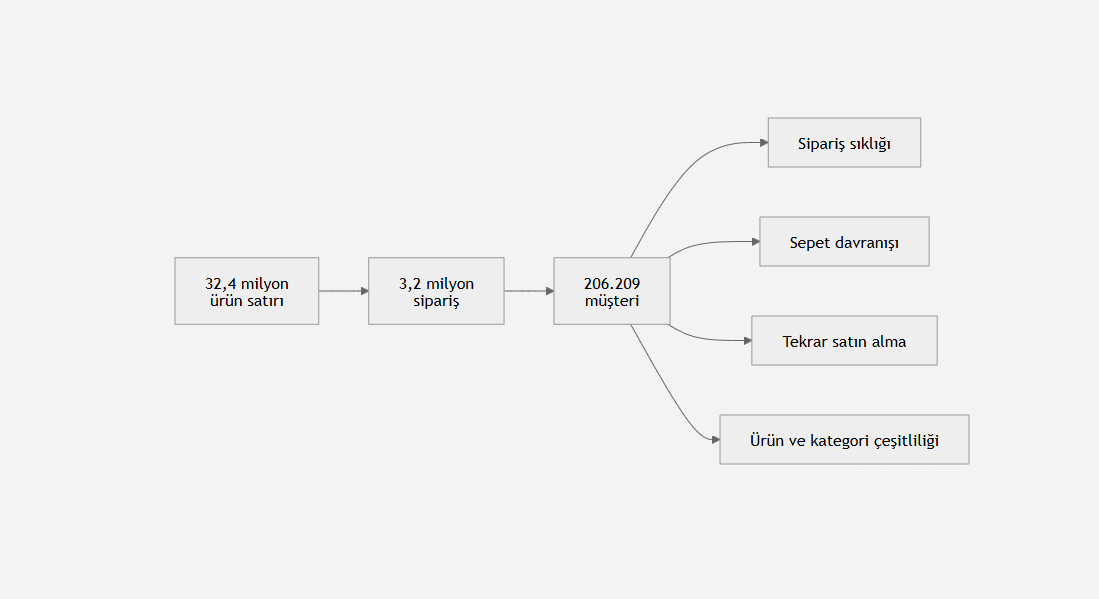

customer_features_raw tablosundaki kolonlar:

user_id: Müşterinin benzersiz kimliği.
total_orders: Müşterinin toplam geçmiş sipariş sayısı.
total_items: Tüm siparişlerdeki toplam farklı ürün satırı sayısı.
avg_basket_size: Sipariş başına ortalama farklı ürün sayısı.
basket_size_std: Sepet büyüklüklerinin ne kadar değişken olduğu.
avg_days_between_orders: Siparişler arasında geçen ortalama gün sayısı.
days_between_orders_std: Sipariş aralıklarının ne kadar değişken olduğu.
reorder_rate: Daha önce alınmış ürünlerin toplam ürün satırlarına oranı.
distinct_products: Geçmişte satın alınan benzersiz ürün sayısı.
product_diversity_ratio: Benzersiz ürün sayısının toplam ürün satırlarına oranı.
distinct_aisles: Alışveriş yapılan farklı reyon sayısı.
distinct_departments: Alışveriş yapılan farklı ana departman sayısı.
top_department_share: En fazla alışveriş yapılan departmanın toplam ürünler içindeki payı.

Bu tabloda bir satır bir müşteriyi temsil eder ve user_id benzersizdir.

## KMeans Müşteri Verisinin Colab’a Aktarılması

BigQuery’de oluşturulan `customer_features_raw` tablosu Python ortamına aktarılmıştır. Veri setinde her satır bir müşteriyi, kolonlar ise müşterilerin sipariş sıklığı, sepet büyüklüğü, yeniden satın alma ve kategori çeşitliliği özelliklerini temsil etmektedir. Toplam 206.209 müşteri ve 13 kolon bulunmaktadır.


In [1]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()

client = bigquery.Client(
    project="wit-final-project-504621"
)

query = """
SELECT *
FROM `wit-final-project-504621.instacart_team_project.customer_features_raw`
"""

customer_features = client.query(query).to_dataframe()

print("Veri boyutu:", customer_features.shape)
display(customer_features.head())

Veri boyutu: (206209, 13)


,user_id,total_orders,total_items,avg_basket_size,basket_size_std,avg_days_between_orders,days_between_orders_std,reorder_rate,distinct_products,product_diversity_ratio,distinct_aisles,distinct_departments,top_department_share
0,95070,3,3,1.0,0.0,28.5,2.121320,0.666667,1,0.333333,1,1,1.0
1,98637,3,3,1.0,0.0,30.0,0.000000,0.666667,1,0.333333,1,1,1.0
2,132700,3,3,1.0,0.0,23.0,9.899495,0.666667,1,0.333333,1,1,1.0
3,36918,3,3,1.0,0.0,25.5,6.363961,0.666667,1,0.333333,1,1,1.0
4,22711,3,3,1.0,0.0,3.5,4.949747,0.666667,1,0.333333,1,1,1.0


Yapı ve eksik değer kontrolü

In [2]:
customer_features.info()

print("\nEksik değer sayıları:")
display(customer_features.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206209 entries, 0 to 206208
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  206209 non-null  Int64  
 1   total_orders             206209 non-null  Int64  
 2   total_items              206209 non-null  Int64  
 3   avg_basket_size          206209 non-null  float64
 4   basket_size_std          206209 non-null  float64
 5   avg_days_between_orders  206209 non-null  float64
 6   days_between_orders_std  206209 non-null  float64
 7   reorder_rate             206209 non-null  float64
 8   distinct_products        206209 non-null  Int64  
 9   product_diversity_ratio  206209 non-null  float64
 10  distinct_aisles          206209 non-null  Int64  
 11  distinct_departments     206209 non-null  Int64  
 12  top_department_share     206209 non-null  float64
dtypes: Int64(6), float64(7)
memory usage: 21.6 MB

Eksik değer 

,0
user_id,0
total_orders,0
total_items,0
avg_basket_size,0
basket_size_std,0
avg_days_between_orders,0
days_between_orders_std,0
reorder_rate,0
distinct_products,0
product_diversity_ratio,0


Yüksek korelasyonlu özellikleri bul.Bu çıktı, aynı müşteri davranışını güçlü şekilde tekrar eden kolonları gösterecek.

In [3]:
import numpy as np
import pandas as pd

feature_columns = [
    column
    for column in customer_features.columns
    if column != "user_id"
]

spearman_corr = customer_features[
    feature_columns
].corr(method="spearman")

upper_triangle = spearman_corr.where(
    np.triu(
        np.ones(spearman_corr.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

high_corr_pairs["absolute_correlation"] = (
    high_corr_pairs["correlation"].abs()
)

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["absolute_correlation"] >= 0.80
    ]
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
)

display(high_corr_pairs)

,feature_1,feature_2,correlation,absolute_correlation
52,reorder_rate,product_diversity_ratio,-1.000000,1.000000
57,distinct_products,distinct_aisles,0.960011,0.960011
63,distinct_aisles,distinct_departments,0.932702,0.932702
16,total_items,distinct_products,0.929296,0.929296
58,distinct_products,distinct_departments,0.879677,0.879677
18,total_items,distinct_aisles,0.876320,0.876320
0,total_orders,total_items,0.825421,0.825421


Model veri setini oluşturma

In [4]:
selected_features = [
    "total_orders",
    "avg_basket_size",
    "avg_days_between_orders",
    "reorder_rate",
    "top_department_share"
]

model_data = customer_features[
    ["user_id"] + selected_features
].copy()

print("Model verisinin boyutu:", model_data.shape)
display(model_data.head())

Model verisinin boyutu: (206209, 6)


,user_id,total_orders,avg_basket_size,avg_days_between_orders,reorder_rate,top_department_share
0,95070,3,1.0,28.5,0.666667,1.0
1,98637,3,1.0,30.0,0.666667,1.0
2,132700,3,1.0,23.0,0.666667,1.0
3,36918,3,1.0,25.5,0.666667,1.0
4,22711,3,1.0,3.5,0.666667,1.0


Çarpık özelliklere dönüşüm uygulama.total_orders ve avg_basket_size sağa çarpık olduğu için log1p dönüşümü uygulayacağız:

In [5]:
model_data["total_orders_log"] = np.log1p(
    model_data["total_orders"]
)

model_data["avg_basket_size_log"] = np.log1p(
    model_data["avg_basket_size"]
)

KMeans’e verilecek nihai kolonları ayırma

In [6]:
model_features = [
    "total_orders_log",
    "avg_basket_size_log",
    "avg_days_between_orders",
    "reorder_rate",
    "top_department_share"
]

X = model_data[model_features].copy()

display(X.head())

,total_orders_log,avg_basket_size_log,avg_days_between_orders,reorder_rate,top_department_share
0,1.386294,0.693147,28.5,0.666667,1.0
1,1.386294,0.693147,30.0,0.666667,1.0
2,1.386294,0.693147,23.0,0.666667,1.0
3,1.386294,0.693147,25.5,0.666667,1.0
4,1.386294,0.693147,3.5,0.666667,1.0


Ölçeklendirme

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=model_features,
    index=X.index
)

display(X_scaled.head())

,total_orders_log,avg_basket_size_log,avg_days_between_orders,reorder_rate,top_department_share
0,-1.333039,-2.822578,1.870525,1.104994,4.12827
1,-1.333039,-2.822578,2.081636,1.104994,4.12827
2,-1.333039,-2.822578,1.096450,1.104994,4.12827
3,-1.333039,-2.822578,1.448302,1.104994,4.12827
4,-1.333039,-2.822578,-1.647995,1.104994,4.12827


Ölçeklendirme kontrolü

In [8]:
scaling_control = pd.DataFrame({
    "mean": X_scaled.mean(),
    "std": X_scaled.std(ddof=0)
})

display(scaling_control)

,mean,std
total_orders_log,4.035651e-16,1.0
avg_basket_size_log,9.978865e-16,1.0
avg_days_between_orders,-2.514012e-16,1.0
reorder_rate,1.124690e-16,1.0
top_department_share,9.328309e-16,1.0


## Model Özelliklerinin Seçilmesi ve Ölçeklendirilmesi

Korelasyon analizi sonucunda aynı müşteri davranışını güçlü biçimde tekrar eden değişkenler belirlenmiştir. `product_diversity_ratio`, `reorder_rate` değişkeninin matematiksel olarak tam tersi olduğu için modelden çıkarılmıştır. Toplam ürün, farklı ürün, farklı reyon ve farklı departman sayıları da müşteri alışveriş hacmiyle yüksek ilişki gösterdiğinden birlikte kullanılmamıştır.

KMeans modelinde müşteri aktivitesi, ortalama sepet büyüklüğü, sipariş sıklığı, yeniden satın alma eğilimi ve kategori yoğunlaşmasını temsil eden beş özellik kullanılmıştır.

Sağa çarpık dağılan toplam sipariş sayısı ve ortalama sepet büyüklüğüne logaritmik dönüşüm uygulanmıştır. Daha sonra bütün model özellikleri StandardScaler ile ortalaması 0 ve standart sapması 1 olacak şekilde ölçeklendirilmiştir. Böylece farklı ölçü birimlerine sahip özelliklerin KMeans uzaklık hesabını orantısız biçimde etkilemesi önlenmiştir.

Elbow analizi

In [9]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

k_values = range(2, 11)
inertia_values = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300
    )

    kmeans.fit(X_scaled)

    inertia_values.append(kmeans.inertia_)

    print(
        f"k = {k} tamamlandı, "
        f"inertia = {kmeans.inertia_:,.2f}"
    )

k = 2 tamamlandı, inertia = 718,590.31
k = 3 tamamlandı, inertia = 589,031.98
k = 4 tamamlandı, inertia = 517,902.49
k = 5 tamamlandı, inertia = 468,595.18
k = 6 tamamlandı, inertia = 432,564.28
k = 7 tamamlandı, inertia = 402,357.77
k = 8 tamamlandı, inertia = 379,422.24
k = 9 tamamlandı, inertia = 359,014.50
k = 10 tamamlandı, inertia = 343,051.51


In [10]:
elbow_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_values
})

elbow_results["inertia_decrease_pct"] = (
    -elbow_results["inertia"].pct_change() * 100
)

display(elbow_results)

,k,inertia,inertia_decrease_pct
0,2,718590.306965,NaN
1,3,589031.984017,18.029512
2,4,517902.494611,12.075658
3,5,468595.184585,9.520578
4,6,432564.277332,7.689133
5,7,402357.772081,6.983125
6,8,379422.240831,5.700283
7,9,359014.501071,5.378636
8,10,343051.505479,4.446337


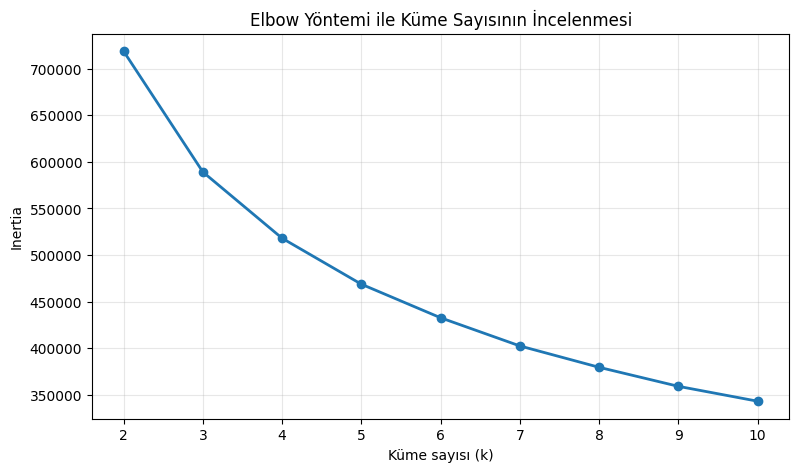

In [11]:
plt.figure(figsize=(9, 5))

plt.plot(
    elbow_results["k"],
    elbow_results["inertia"],
    marker="o",
    linewidth=2
)

plt.xticks(list(k_values))
plt.xlabel("Küme sayısı (k)")
plt.ylabel("Inertia")
plt.title("Elbow Yöntemi ile Küme Sayısının İncelenmesi")
plt.grid(alpha=0.3)

plt.show()

## Elbow Yöntemi

Uygun küme sayısını değerlendirmek amacıyla 2 ile 10 arasındaki farklı küme sayıları için KMeans modelleri kurulmuştur. Her modelin küme içi hata düzeyini gösteren inertia değeri hesaplanmıştır.

Küme sayısı arttıkça inertia doğal olarak düşmektedir. Bu nedenle en düşük değer doğrudan seçilmemiş; inertia düşüşünün belirgin biçimde yavaşlamaya başladığı dirsek noktası incelenmiştir. Elbow sonucu tek başına nihai karar olarak kullanılmamış, Silhouette Score sonuçlarıyla birlikte değerlendirilmesi planlanmıştır.

Silhouette Score

Silhouette, basitçe şu soruyu sorar:

Müşteri kendi kümesine mi daha yakın, yoksa diğer kümelere mi?

Değer yükseldikçe kümelerin ayrımı genel olarak daha iyidir:

1e yakın: İyi ayrılmış
0a yakın: Kümeler iç içe
Negatif: Bazı müşteriler yanlış kümeye yakın olabilir

In [12]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd

silhouette_results = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_results.append({
        "k": k,
        "silhouette_score": score
    })

    print(
        f"k = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

silhouette_results = pd.DataFrame(
    silhouette_results
)

display(silhouette_results)

k = 2, Silhouette Score = 0.2736
k = 3, Silhouette Score = 0.2664
k = 4, Silhouette Score = 0.2057
k = 5, Silhouette Score = 0.1992
k = 6, Silhouette Score = 0.1862


,k,silhouette_score
0,2,0.273555
1,3,0.266427
2,4,0.205666
3,5,0.199209
4,6,0.186188


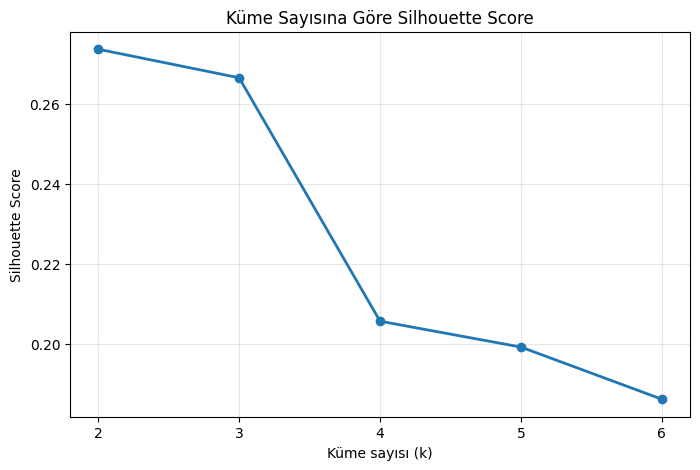

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_results["k"],
    silhouette_results["silhouette_score"],
    marker="o",
    linewidth=2
)

plt.xticks(silhouette_results["k"])
plt.xlabel("Küme sayısı (k)")
plt.ylabel("Silhouette Score")
plt.title("Küme Sayısına Göre Silhouette Score")
plt.grid(alpha=0.3)

plt.show()

### Elbow Analizi Sonucu

Elbow grafiğinde en yüksek iyileşme 2 kümeden 3 kümeye geçişte görülmüştür. Üç kümeden dört kümeye geçişte de anlamlı bir iyileşme bulunmakla birlikte, dört kümeden sonra inertia değerindeki azalma giderek yavaşlamıştır. Bu nedenle 3 ve 4 küme öncelikli adaylar olarak belirlenmiştir. Nihai küme sayısına yalnızca Elbow grafiğiyle karar verilmemiş, Silhouette Score sonuçları da değerlendirmeye alınmıştır.

### Nihai Küme Sayısının Belirlenmesi

Silhouette Score en yüksek değerini 2 kümede almıştır. Bununla birlikte 3 kümenin skoru 2 kümeye oldukça yakınken, 4 ve daha fazla kümede skor belirgin biçimde düşmüştür. Elbow grafiğinde de 3 kümeye kadar güçlü bir iyileşme görülmüştür.

İki kümenin müşterileri çok geniş iki gruba ayıracağı değerlendirilmiştir. Bu nedenle ayrışma kalitesi ile iş açısından yorumlanabilir segment sayısı arasında denge kurularak nihai küme sayısı 3 olarak belirlenmiştir.

Nihai KMeans modeli

In [14]:
final_k = 3

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10,
    max_iter=300
)

final_labels = final_kmeans.fit_predict(
    X_scaled
)

print("Oluşturulan cluster etiketleri:")
print(np.unique(final_labels))

Oluşturulan cluster etiketleri:
[0 1 2]


Cluster etiketlerini müşterilere ekle

In [15]:
customer_segments = customer_features.copy()

customer_segments["cluster"] = final_labels

display(
    customer_segments[
        [
            "user_id",
            "total_orders",
            "avg_basket_size",
            "avg_days_between_orders",
            "reorder_rate",
            "top_department_share",
            "cluster"
        ]
    ].head()
)

,user_id,total_orders,avg_basket_size,avg_days_between_orders,reorder_rate,top_department_share,cluster
0,95070,3,1.0,28.5,0.666667,1.0,2
1,98637,3,1.0,30.0,0.666667,1.0,2
2,132700,3,1.0,23.0,0.666667,1.0,2
3,36918,3,1.0,25.5,0.666667,1.0,2
4,22711,3,1.0,3.5,0.666667,1.0,2


Cluster büyüklükleri

In [16]:
cluster_distribution = (
    customer_segments["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="customer_count")
)

cluster_distribution["customer_share_pct"] = (
    cluster_distribution["customer_count"]
    / len(customer_segments)
    * 100
)

cluster_distribution["customer_share_pct"] = (
    cluster_distribution["customer_share_pct"]
    .round(2)
)

display(cluster_distribution)

,cluster,customer_count,customer_share_pct
0,0,94802,45.97
1,1,75136,36.44
2,2,36271,17.59


In [17]:
cluster_profile = (
    customer_segments
    .groupby("cluster")
    .agg(
        customer_count=("user_id", "count"),
        avg_total_orders=("total_orders", "mean"),
        avg_basket_size=("avg_basket_size", "mean"),
        avg_days_between_orders=(
            "avg_days_between_orders",
            "mean"
        ),
        avg_reorder_rate=("reorder_rate", "mean"),
        avg_top_department_share=(
            "top_department_share",
            "mean"
        )
    )
    .reset_index()
)

cluster_profile["customer_share_pct"] = (
    cluster_profile["customer_count"]
    / len(customer_segments)
    * 100
)

cluster_profile["avg_reorder_rate"] *= 100
cluster_profile["avg_top_department_share"] *= 100

cluster_profile = cluster_profile.round(2)

display(cluster_profile)

,cluster,customer_count,avg_total_orders,avg_basket_size,avg_days_between_orders,avg_reorder_rate,avg_top_department_share,customer_share_pct
0,0,94802,6.56,11.09,18.59,28.27,31.14,45.97
1,1,75136,30.15,11.16,9.90,61.67,34.35,36.44
2,2,36271,9.02,4.48,17.37,44.11,57.82,17.59


In [19]:
segment_name_map = {
    0: "Seyrek ve Keşif Odaklı",
    1: "Aktif ve Sadık",
    2: "Kategori Odaklı Küçük Sepetli"
}

customer_segments["segment_name"] = (
    customer_segments["cluster"]
    .map(segment_name_map)
)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

segment_name_map = {
    0: "Seyrek ve\nKeşif Odaklı",
    1: "Aktif ve\nSadık",
    2: "Kategori Odaklı\nKüçük Sepetli"
}

customer_segments["segment_name"] = (
    customer_segments["cluster"]
    .map(segment_name_map)
)

# Grafiklerde kullanılacak özet tablo
visual_profile = (
    customer_segments
    .groupby(["cluster", "segment_name"])
    .agg(
        customer_count=("user_id", "count"),
        avg_total_orders=("total_orders", "mean"),
        avg_basket_size=("avg_basket_size", "mean"),
        avg_days_between_orders=(
            "avg_days_between_orders",
            "mean"
        ),
        avg_reorder_rate=("reorder_rate", "mean"),
        avg_top_department_share=(
            "top_department_share",
            "mean"
        )
    )
    .reset_index()
    .sort_values("cluster")
)

# Oranları yüzdeye çevir
visual_profile["customer_share_pct"] = (
    visual_profile["customer_count"]
    / len(customer_segments)
    * 100
)

visual_profile["avg_reorder_rate_pct"] = (
    visual_profile["avg_reorder_rate"] * 100
)

visual_profile["avg_top_department_share_pct"] = (
    visual_profile["avg_top_department_share"] * 100
)

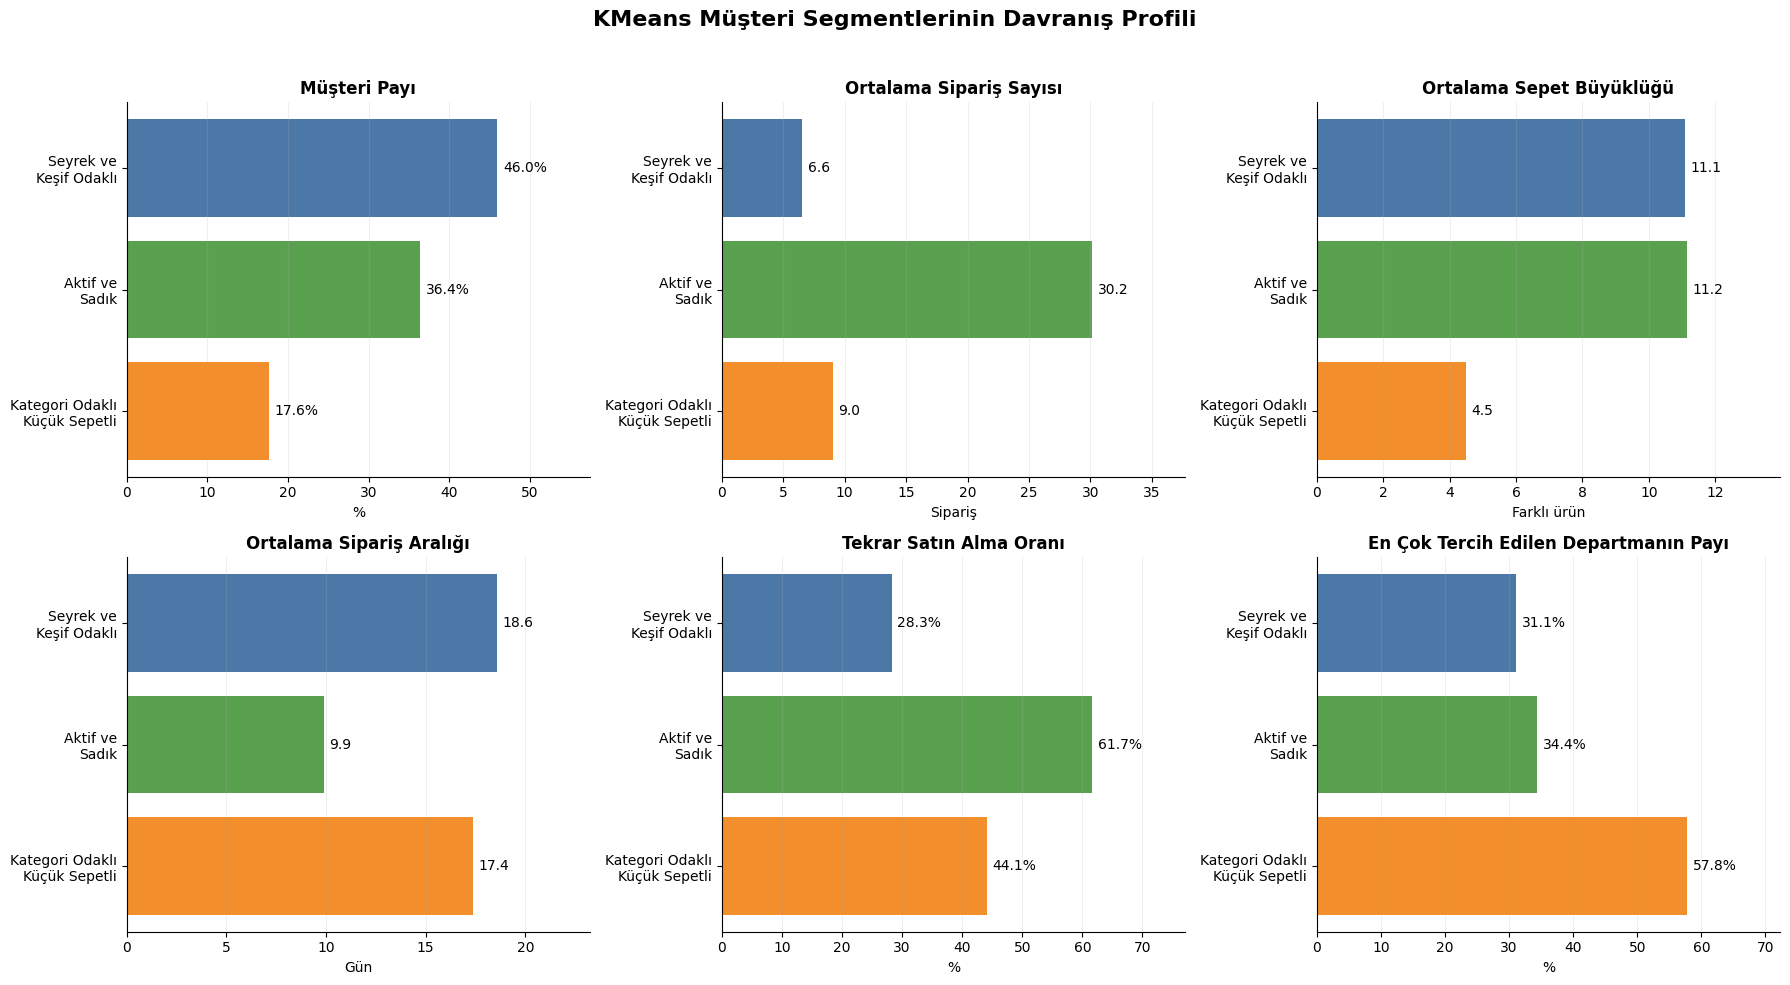

In [23]:
metrics = [
    (
        "customer_share_pct",
        "Müşteri Payı",
        "%",
        "{:.1f}%"
    ),
    (
        "avg_total_orders",
        "Ortalama Sipariş Sayısı",
        "Sipariş",
        "{:.1f}"
    ),
    (
        "avg_basket_size",
        "Ortalama Sepet Büyüklüğü",
        "Farklı ürün",
        "{:.1f}"
    ),
    (
        "avg_days_between_orders",
        "Ortalama Sipariş Aralığı",
        "Gün",
        "{:.1f}"
    ),
    (
        "avg_reorder_rate_pct",
        "Tekrar Satın Alma Oranı",
        "%",
        "{:.1f}%"
    ),
    (
        "avg_top_department_share_pct",
        "En Çok Tercih Edilen Departmanın Payı",
        "%",
        "{:.1f}%"
    )
]

segment_colors = [
    "#4C78A8",
    "#59A14F",
    "#F28E2B"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for ax, (column, title, unit, label_format) in zip(
    axes,
    metrics
):
    values = visual_profile[column]

    bars = ax.barh(
        visual_profile["segment_name"],
        values,
        color=segment_colors
    )

    value_labels = [
        label_format.format(value)
        for value in values
    ]

    ax.bar_label(
        bars,
        labels=value_labels,
        padding=4,
        fontsize=10
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(unit)
    ax.set_ylabel("")

    ax.set_xlim(
        0,
        values.max() * 1.25
    )

    ax.invert_yaxis()
    ax.grid(
        axis="x",
        alpha=0.2
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "KMeans Müşteri Segmentlerinin Davranış Profili",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

## Müşteri Segmentlerinin Yorumlanması

KMeans modeli sonucunda müşteriler üç segmente ayrılmıştır. Segmentler, cluster numaralarına göre değil; müşterilerin sipariş sayısı, sepet büyüklüğü, sipariş aralığı, yeniden satın alma oranı ve kategori yoğunlaşması dikkate alınarak isimlendirilmiştir.

İlk segment seyrek alışveriş yapan, tekrar satın alma oranı düşük ve alışverişi farklı kategorilere yayılan müşterilerden oluşmaktadır. İkinci segment sık sipariş veren ve aynı ürünleri yeniden satın alma eğilimi yüksek aktif müşterileri içermektedir. Üçüncü segment ise küçük sepetlerle alışveriş yapan ve ürün tercihleri belirli bir departmanda yoğunlaşan müşterilerden oluşmaktadır.

Segment isimleri müşterilerin kârlılığını veya parasal değerini ifade etmemektedir. Veri setinde fiyat ve gelir bilgisi bulunmadığından segmentler yalnızca gözlemlenen alışveriş davranışları üzerinden yorumlanmıştır.

KMeans Sonuç Tablolarının Oluşturulması

KMeans modeli sonucunda her müşteriye bir küme numarası atanmıştır. Küme numaraları tek başına iş anlamı taşımadığı için kümeler, müşteri davranış profillerine göre isimlendirilmiştir.

İki sonuç tablosu oluşturulmuştur:

customer_segments_kmeans: Her müşterinin özelliklerini ve ait olduğu segmenti içerir.
cluster_profiles: Segmentlerin müşteri sayısını, toplam müşteri içindeki payını ve ortalama davranış özelliklerini içerir.

Sonuç tabloları wit-final-project-504621.instacart_team_project dataset’ine yazılmıştır. Kaynak tablolarda herhangi bir değişiklik yapılmamıştır.

In [24]:
# Cluster numaralarını iş açısından anlamlı segment isimleriyle eşleştiriyoruz.
segment_name_map = {
    0: "Seyrek ve Keşif Odaklı",
    1: "Aktif ve Sadık",
    2: "Kategori Odaklı Küçük Sepetli"
}

# Her müşteriye segment ismini ekliyoruz.
customer_segments["segment_name"] = (
    customer_segments["cluster"].map(segment_name_map)
)

# BigQuery'e yazılacak kolonları belirliyoruz.
customer_segments_output = customer_segments[
    [
        "user_id",
        "cluster",
        "segment_name",
        "total_orders",
        "total_items",
        "avg_basket_size",
        "basket_size_std",
        "avg_days_between_orders",
        "days_between_orders_std",
        "reorder_rate",
        "distinct_products",
        "product_diversity_ratio",
        "distinct_aisles",
        "distinct_departments",
        "top_department_share"
    ]
].copy()

# BigQuery veri tipleriyle uyumlu olması için kimlik kolonlarını düzenliyoruz.
customer_segments_output["user_id"] = (
    customer_segments_output["user_id"].astype("int64")
)

customer_segments_output["cluster"] = (
    customer_segments_output["cluster"].astype("int64")
)

display(customer_segments_output.head())
print("Tablo boyutu:", customer_segments_output.shape)

,user_id,cluster,segment_name,total_orders,total_items,avg_basket_size,basket_size_std,avg_days_between_orders,days_between_orders_std,reorder_rate,distinct_products,product_diversity_ratio,distinct_aisles,distinct_departments,top_department_share
0,95070,2,Kategori Odaklı Küçük Sepetli,3,3,1.0,0.0,28.5,2.121320,0.666667,1,0.333333,1,1,1.0
1,98637,2,Kategori Odaklı Küçük Sepetli,3,3,1.0,0.0,30.0,0.000000,0.666667,1,0.333333,1,1,1.0
2,132700,2,Kategori Odaklı Küçük Sepetli,3,3,1.0,0.0,23.0,9.899495,0.666667,1,0.333333,1,1,1.0
3,36918,2,Kategori Odaklı Küçük Sepetli,3,3,1.0,0.0,25.5,6.363961,0.666667,1,0.333333,1,1,1.0
4,22711,2,Kategori Odaklı Küçük Sepetli,3,3,1.0,0.0,3.5,4.949747,0.666667,1,0.333333,1,1,1.0


Tablo boyutu: (206209, 15)


Segment profil tablosunu hazırlama

In [25]:
cluster_profiles_output = (
    customer_segments_output
    .groupby(["cluster", "segment_name"], as_index=False)
    .agg(
        customer_count=("user_id", "count"),
        avg_total_orders=("total_orders", "mean"),
        avg_basket_size=("avg_basket_size", "mean"),
        avg_days_between_orders=("avg_days_between_orders", "mean"),
        avg_reorder_rate=("reorder_rate", "mean"),
        avg_top_department_share=("top_department_share", "mean")
    )
)

# Müşterilerin yüzde kaçının ilgili segmentte olduğunu hesaplıyoruz.
cluster_profiles_output["customer_share_pct"] = (
    cluster_profiles_output["customer_count"]
    / cluster_profiles_output["customer_count"].sum()
    * 100
)

# Oranları daha kolay okunması için yüzde biçimine dönüştürüyoruz.
cluster_profiles_output["avg_reorder_rate_pct"] = (
    cluster_profiles_output["avg_reorder_rate"] * 100
)

cluster_profiles_output["avg_top_department_share_pct"] = (
    cluster_profiles_output["avg_top_department_share"] * 100
)

# Artık ihtiyaç olmayan ondalık oran kolonlarını kaldırıyoruz.
cluster_profiles_output = cluster_profiles_output.drop(
    columns=["avg_reorder_rate", "avg_top_department_share"]
)

# Sonuçları iki ondalık basamağa yuvarlıyoruz.
numeric_columns = cluster_profiles_output.select_dtypes(
    include="number"
).columns

cluster_profiles_output[numeric_columns] = (
    cluster_profiles_output[numeric_columns].round(2)
)

display(cluster_profiles_output)

,cluster,segment_name,customer_count,avg_total_orders,avg_basket_size,avg_days_between_orders,customer_share_pct,avg_reorder_rate_pct,avg_top_department_share_pct
0,0,Seyrek ve Keşif Odaklı,94802,6.56,11.09,18.59,45.97,28.27,31.14
1,1,Aktif ve Sadık,75136,30.15,11.16,9.90,36.44,61.67,34.35
2,2,Kategori Odaklı Küçük Sepetli,36271,9.02,4.48,17.37,17.59,44.11,57.82


Tabloları BigQuery’e yazma

In [26]:
from google.cloud import bigquery

project_id = "wit-final-project-504621"
dataset_id = "instacart_team_project"

client = bigquery.Client(project=project_id)

# WRITE_TRUNCATE:
# Tablo daha önce varsa yalnızca bu sonuç tablosunu yeniler.
# Ham kaynak tabloları etkilemez.
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE"
)

customer_table_id = (
    f"{project_id}.{dataset_id}.customer_segments_kmeans"
)

profile_table_id = (
    f"{project_id}.{dataset_id}.cluster_profiles"
)

customer_job = client.load_table_from_dataframe(
    customer_segments_output,
    customer_table_id,
    job_config=job_config
)

customer_job.result()

profile_job = client.load_table_from_dataframe(
    cluster_profiles_output,
    profile_table_id,
    job_config=job_config
)

profile_job.result()

print("Oluşturulan tablo:", customer_table_id)
print("Oluşturulan tablo:", profile_table_id)

Oluşturulan tablo: wit-final-project-504621.instacart_team_project.customer_segments_kmeans
Oluşturulan tablo: wit-final-project-504621.instacart_team_project.cluster_profiles


Yazma işlemini kontrol etme

In [27]:
customer_table = client.get_table(customer_table_id)
profile_table = client.get_table(profile_table_id)

print(
    "customer_segments_kmeans satır sayısı:",
    customer_table.num_rows
)

print(
    "cluster_profiles satır sayısı:",
    profile_table.num_rows
)

customer_segments_kmeans satır sayısı: 206209
cluster_profiles satır sayısı: 3
